# Stage I - structural MRI measurement differences of numerical variability

## Cortical Surface Area

### Cohens'd coefficient

Let $X_1$ and $X_2$ represent two distinct populations with $|X_1|=N$, $|X_2|=M$. Cohen's d is defined as:
$$
d = \frac{\mu_1 - \mu_2}{\sigma_{\text{pooled}}},
$$
where $\mu_1$ and $\mu_2$ are the means of populations $X_1$ and $X_2$, respectively, and $\sigma_{\text{pooled}}$ is the pooled standard deviation given by:
$$
\sigma_{\text{pooled}} = \sqrt{\frac{(N-1)\sigma^{2}_{X_1} + (M-1)\sigma^{2}_{X_2}}{N + M - 2}}.
$$

## Cohens'd coefficent standard deviation estimation

To estimate the standard deviation of the Cohen's d coefficient, we 
split the population in two groups of equal size with equal proportion of PD and HC within each group.
We then compute the d coefficient for each MCA repetition, leading to 26 Cohen's d estimate.
The process is repeated 1000 times to sample the population variability.
Confidence interval for standard deviation is estimated using boostrap method.

### Cohen's variability

Split population in two equal groups $X_1$, $X_2$.
Compute $N$ times (N being the number of MCA repetitions) the Cohen coefficient.
Compute the standard deviation among the Cohen's d distribution.

## Numerical-Anatomical Variability Ratio

$$
\mathrm{NAVR} = \dfrac{\sigma_{num}}{\sigma_{anat}}
$$

## Relationship between NAVR and d

$$
d = \frac{2}{\sqrt{D}} \dfrac{\sigma_{num}}{\sigma_{anat}}
$$
where $D$ is the total population size

In [20]:
import pandas as pd
import os
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
from pathlib import Path
from IPython.display import Image, display
import plotly.graph_objects as go

import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

TESTING = False  # Set to True to run a smaller test

root_dir = Path(
    os.path.dirname(os.getcwd())
)  # Use current working directory as root_dir
print("Running in root dir: ", root_dir.name)
stats_dir = root_dir / "stats_QCed" / "sampled"
print("Stats directory:", stats_dir)

output_dir = root_dir / "cohen_d"
os.makedirs(output_dir, exist_ok=True)
figures_dir = output_dir / "figures"
os.makedirs(figures_dir, exist_ok=True)
csv_dir = output_dir / "csv"
os.makedirs(csv_dir, exist_ok=True)

rng = np.random.default_rng(42)

Running in root dir:  freesurfer-fuzzy
Stats directory: /mnt/lustre/ychatel/living-park/VIP-python-client/example/freesurfer-fuzzy/stats_QCed/sampled


In [21]:
regions_template = [
    "bankssts",
    "caudalanteriorcingulate",
    "caudalmiddlefrontal",
    "cuneus",
    "entorhinal",
    "fusiform",
    "inferiorparietal",
    "inferiortemporal",
    "isthmuscingulate",
    "lateraloccipital",
    "lateralorbitofrontal",
    "lingual",
    "medialorbitofrontal",
    "middletemporal",
    "parahippocampal",
    "paracentral",
    "parsopercularis",
    "parsorbitalis",
    "parstriangularis",
    "pericalcarine",
    "postcentral",
    "posteriorcingulate",
    "precentral",
    "precuneus",
    "rostralanteriorcingulate",
    "rostralmiddlefrontal",
    "superiorfrontal",
    "superiorparietal",
    "superiortemporal",
    "supramarginal",
    "frontalpole",
    "temporalpole",
    "transversetemporal",
    "insula",
]


In [22]:
def print_figure(fig, filename):
    display(fig)
    fig.write_image(filename)
    display(Image(filename=filename))

In [23]:
def assert_number_of_repetitions(df, hemisphere=None, repetitions=26):
    """
    Assert that each subjects/region has exactly N repetitions.
    """
    groups = ["subjects", "region"] + (["hemisphere"] if hemisphere else [])
    grouped = df.groupby(groups).count() == repetitions
    assert grouped.all().all(), (
        f"Not all subjects/regions have {repetitions} repetitions. {grouped[grouped == False].count()}"
    )


In [24]:
def get_cohort_stat():
    df_cohort = pd.read_csv("../cohort_stat.csv")
    print(f"Load cohort stats: {os.path.abspath('../cohort_stat.csv')}")
    columns = [
        "PATNO",
        "first_visit",
        "second_visit",
        "dx_group",
        "SEX",
        "AGE_AT_VISIT",
    ]
    df_cohort["first_visit"] = (
        "sub-"
        + df_cohort["PATNO"].astype(str)
        + "_ses-"
        + df_cohort["EVENT_ID"].astype(str)
    )
    df_cohort["second_visit"] = (
        "sub-"
        + df_cohort["PATNO"].astype(str)
        + "_ses-"
        + df_cohort["NEXT_VISIT"].astype(str)
    )
    print(f"Number of PD-non-MCI + HC subjects: {df_cohort.shape[0]}")
    return df_cohort[columns]


df_cohort = get_cohort_stat()


Load cohort stats: /mnt/lustre/ychatel/living-park/VIP-python-client/example/freesurfer-fuzzy/cohort_stat.csv
Number of PD-non-MCI + HC subjects: 295


In [25]:
split_subjects_randomly = True


def get_populations(rng, get_hash=None):
    df = pd.read_parquet(stats_dir / "thickness.parquet")
    cohort_subjects = np.concatenate(
        [df_cohort["first_visit"].unique(), df_cohort["second_visit"].unique()]
    )
    df = df[df["subjects"].isin(cohort_subjects)]

    pd_df = df[df["PD_status"] == "PD"]
    hc_df = df[df["PD_status"] == "HC"]
    pd_subjects = pd_df["subjects"].unique()
    hc_subjects = hc_df["subjects"].unique()
    rng.shuffle(pd_subjects)
    rng.shuffle(hc_subjects)
    [pop1_pd, pop2_pd] = np.array_split(pd_subjects, 2)
    [pop1_hc, pop2_hc] = np.array_split(hc_subjects, 2)
    pop1 = np.concatenate([pop1_pd, pop1_hc])
    pop2 = np.concatenate([pop2_pd, pop2_hc])
    # compute hash to check if sequences has changed
    pop1_hash = hex(hash(tuple(pop1)))
    pop2_hash = hex(hash(tuple(pop2)))
    if get_hash:
        return pop1, pop2, pop1_hash, pop2_hash

    return pop1, pop2

In [26]:
def get_stats_metric(metric, hemisphere=None):
    df = pd.read_parquet(stats_dir / f"{metric}.parquet")
    if hemisphere:
        df = df.rename(columns={"hemi": "hemisphere"})
    df.drop(
        columns=[
            "PATNO_id",
            "dx_group",
            "PD_status",
            "image_name",
            "path",
            "rejected_images",
            "input_dir",
        ],
        inplace=True,
        errors="ignore",
    )
    df["repetition"] = (
        df.groupby(["subjects"] + (["hemisphere"] if hemisphere else [])).cumcount() + 1
    )
    id_vars = ["repetition", "subjects"]
    id_vars += ["hemisphere"] if hemisphere else []
    df = df.melt(id_vars=id_vars, var_name="region", value_name=metric)
    df["region"] = df["region"].str.replace(f"_{metric}", "", regex=False)
    # Convert all numerics columns to np.float64
    for col in df.select_dtypes(include=["number"]).columns:
        df[col] = df[col].astype(np.float64)
    assert_number_of_repetitions(df, hemisphere=hemisphere, repetitions=26)
    return df

In [27]:
cohort = pd.read_csv("../cohort_stat.csv")
print(f"Load cohort stats: {os.path.abspath('../cohort_stat.csv')}")

pop1, pop2 = get_populations(rng)

subjects = cohort["PATNO_id"].unique()
hc_subjects = cohort[cohort.dx_group == "HC"]["PATNO_id"].unique()
pd_subjects = cohort[cohort.dx_group != "HC"]["PATNO_id"].unique()

print(f"Number of subjects in pop1: {len(pop1)}")
print(f"Number of subjects in pop2: {len(pop2)}")


def print_population_stats(number, population, cohort):
    hc_subjects = cohort[cohort.dx_group == "HC"]["PATNO_id"].unique()
    pd_subjects = cohort[cohort.dx_group != "HC"]["PATNO_id"].unique()
    hc_subjects_pop = np.intersect1d(hc_subjects, population)
    pd_subjects_pop = np.intersect1d(pd_subjects, population)
    print("-" * 20)
    print(
        f"Population {number} HC subjects: {len(hc_subjects_pop)}, PD subjects: {len(pd_subjects_pop)}"
    )

    hc_ratio = len(hc_subjects_pop) / len(population)
    pd_ratio = len(pd_subjects_pop) / len(population)

    print(f"Population {number} HC ratio: {hc_ratio:.2f}, PD ratio: {pd_ratio:.2f}")


print_population_stats(1, pop1, cohort)
print_population_stats(2, pop2, cohort)


def print_age_stats(number, population, cohort):
    hc_subjects = cohort[cohort.dx_group == "HC"]["PATNO_id"].unique()
    pd_subjects = cohort[cohort.dx_group != "HC"]["PATNO_id"].unique()
    hc_subjects_pop = np.intersect1d(hc_subjects, population)
    pd_subjects_pop = np.intersect1d(pd_subjects, population)

    hc_ages_pop = cohort[cohort.dx_group == "HC"].loc[
        cohort["PATNO_id"].isin(hc_subjects_pop), "AGE_AT_VISIT"
    ]
    pd_ages_pop = cohort[cohort.dx_group != "HC"].loc[
        cohort["PATNO_id"].isin(pd_subjects_pop), "AGE_AT_VISIT"
    ]

    hc_age_avg = hc_ages_pop.mean()
    pd_age_avg = pd_ages_pop.mean()

    hc_age_std = hc_ages_pop.std()
    pd_age_std = pd_ages_pop.std()

    print(
        f"Population {number} HC age average: {hc_age_avg:.2f} ± {hc_age_std:.2f}, PD age average: {pd_age_avg:.2f} ± {pd_age_std:.2f}"
    )


print_age_stats(1, pop1, cohort)
print_age_stats(2, pop2, cohort)


def print_gender_stats(number, population, cohort):
    hc_subjects = cohort[cohort.dx_group == "HC"]["PATNO_id"].unique()
    pd_subjects = cohort[cohort.dx_group != "HC"]["PATNO_id"].unique()
    hc_subjects_pop = np.intersect1d(hc_subjects, population)
    pd_subjects_pop = np.intersect1d(pd_subjects, population)

    hc_gender_pop = cohort[cohort.dx_group == "HC"].loc[
        cohort["PATNO_id"].isin(hc_subjects_pop), "SEX"
    ]
    pd_gender_pop = cohort[cohort.dx_group != "HC"].loc[
        cohort["PATNO_id"].isin(pd_subjects_pop), "SEX"
    ]

    hc_gender_counts = hc_gender_pop.value_counts()
    hc_gender_m = hc_gender_counts.get(1)
    hc_gender_f = hc_gender_counts.get(0)

    pd_gender_counts = pd_gender_pop.value_counts()
    pd_gender_m = pd_gender_counts.get(1)
    pd_gender_f = pd_gender_counts.get(0)

    hc_gender_m_ratio = hc_gender_m / (hc_gender_m + hc_gender_f)
    hc_gender_f_ratio = hc_gender_f / (hc_gender_m + hc_gender_f)
    pd_gender_m_ratio = pd_gender_m / (pd_gender_m + pd_gender_f)
    pd_gender_f_ratio = pd_gender_f / (pd_gender_m + pd_gender_f)

    print("-" * 20)
    print(
        f"Population {number} HC M / F count: {hc_gender_m} / {hc_gender_f}, PD M / F count: {pd_gender_m} / {pd_gender_f}"
    )
    print(
        f"Population {number} HC M / F ratio: {hc_gender_m_ratio:.2f} / {hc_gender_f_ratio:.2f}, PD M / F ratio: {pd_gender_m_ratio:.2f} / {pd_gender_f_ratio:.2f}"
    )


print_gender_stats(1, pop1, cohort)
print_gender_stats(2, pop2, cohort)

Load cohort stats: /mnt/lustre/ychatel/living-park/VIP-python-client/example/freesurfer-fuzzy/cohort_stat.csv
Number of subjects in pop1: 284
Number of subjects in pop2: 282
--------------------
Population 1 HC subjects: 53, PD subjects: 97
Population 1 HC ratio: 0.19, PD ratio: 0.34
--------------------
Population 2 HC subjects: 47, PD subjects: 95
Population 2 HC ratio: 0.17, PD ratio: 0.34
Population 1 HC age average: 59.16 ± 9.57, PD age average: 62.01 ± 9.92
Population 2 HC age average: 61.26 ± 10.31, PD age average: 62.77 ± 9.24
--------------------
Population 1 HC M / F count: 30 / 23, PD M / F count: 64 / 33
Population 1 HC M / F ratio: 0.57 / 0.43, PD M / F ratio: 0.66 / 0.34
--------------------
Population 2 HC M / F count: 24 / 23, PD M / F count: 62 / 33
Population 2 HC M / F ratio: 0.51 / 0.49, PD M / F ratio: 0.65 / 0.35


In [28]:
def compute_stat(df, stat, hemi):
    if hemi:
        stat = (
            df.drop(columns=["repetition", "subjects"])
            .groupby(["hemisphere", "region"])
            .apply(stat)
            .reset_index()
        )
    else:
        stat = (
            df.drop(columns=["repetition", "subjects"])
            .groupby(["region"])
            .apply(stat)
            .reset_index()
        )
    return stat


def compute_mean(df, hemi):
    return compute_stat(df, "mean", hemi)


def compute_var(df, hemi):
    return compute_stat(df, "var", hemi)


def compute_std(df, hemi):
    return compute_stat(df, "std", hemi)


In [29]:
def compute_cortical_variability_cohen_d(metric, population_1, population_2):
    """
    Computes Cohen's d for the given metric between two populations.
    """
    df = get_stats_metric(metric, hemisphere=True)

    columns = [
        "repetition",
        "region",
        "mean_pop1",
        "std_pop1",
        "var_pop1",
        "mean_pop2",
        "std_pop2",
        "var_pop2",
        "pooled_std",
        "cohen_d",
    ]
    cohen_d_df = pd.DataFrame(columns=columns)

    repetitions = df["repetition"].unique()
    for rep in repetitions:
        # Get population 1
        df1_rep = df[df["repetition"] == rep]
        df1_rep = df1_rep[df1_rep["subjects"].isin(population_1)]
        n1 = df1_rep["subjects"].nunique()
        # Compute mean, var, std for population 1

        mean_pop1 = compute_mean(df1_rep, hemi=True)
        var_pop1 = compute_var(df1_rep, hemi=True)
        std_pop1 = compute_std(df1_rep, hemi=True)

        # Get population 2
        df2_rep = df[df["repetition"] == rep]
        df2_rep = df2_rep[df2_rep["subjects"].isin(population_2)]
        n2 = df2_rep["subjects"].nunique()
        # Compute mean, var, std for population 2
        mean_pop2 = compute_mean(df2_rep, hemi=True)
        var_pop2 = compute_var(df2_rep, hemi=True)
        std_pop2 = compute_std(df2_rep, hemi=True)

        pooled_var = ((n1 - 1) * var_pop1[metric] + (n2 - 1) * var_pop2[metric]) / (
            n1 + n2 - 2
        )
        pooled_std = np.sqrt(pooled_var)

        stats = {"mean": None}
        for stat in stats.keys():
            if stat == "mean":
                stats[stat] = (mean_pop1[metric] - mean_pop2[metric]) / pooled_std

        cohen_d_mean = stats["mean"]

        # Create a DataFrame to display the results
        cohen_d_df_rep = pd.DataFrame(columns=columns)
        assert (mean_pop1.hemisphere == mean_pop2.hemisphere).all(), (
            "Hemisphere mismatch between populations"
        )
        assert (mean_pop1.region == mean_pop2.region).all(), (
            "Region mismatch between populations"
        )
        cohen_d_df_rep["hemisphere"] = mean_pop1.hemisphere
        cohen_d_df_rep["region"] = mean_pop1.region
        cohen_d_df_rep["mean_pop1"] = mean_pop1[metric]
        cohen_d_df_rep["std_pop1"] = std_pop1[metric]
        cohen_d_df_rep["var_pop1"] = var_pop1[metric]
        cohen_d_df_rep["mean_pop2"] = mean_pop2[metric]
        cohen_d_df_rep["std_pop2"] = std_pop2[metric]
        cohen_d_df_rep["var_pop2"] = var_pop2[metric]
        cohen_d_df_rep["pooled_std"] = pooled_std
        cohen_d_df_rep["cohen_d_mean"] = cohen_d_mean
        cohen_d_df_rep["repetition"] = rep

        # Append the DataFrame to the main DataFrame
        if cohen_d_df.empty:
            cohen_d_df = cohen_d_df_rep
        else:
            cohen_d_df = pd.concat([cohen_d_df, cohen_d_df_rep], axis=0)

    cohen_d_df["region"] = cohen_d_df["region"].str.replace(
        f"_{metric}", "", regex=False
    )
    return cohen_d_df.reset_index(drop=True)

In [30]:
def compute_numerical_variability_cortical_metric(metric, population):
    df = get_stats_metric(metric, hemisphere=True)
    df = df[df["subjects"].isin(population)]
    df[metric] = df[metric].astype(np.float64)
    Card = df.subjects.nunique()
    display(f"Number unique subjects/visits in population: {Card}")
    numerical = (
        df.drop(columns=["repetition"])
        .groupby(["hemisphere", "region", "subjects"])
        .var()
        .reset_index()
    )
    return Card, numerical


def compute_anatomical_variability_cortical_metric(metric, population):
    df = get_stats_metric(metric, hemisphere=True)
    df = df[df["subjects"].isin(population)]
    df[metric] = df[metric].astype(np.float64)
    card = df.subjects.nunique()
    display(f"Number unique subjects/visits in population: {card}")

    # Compute the average among MCA repetition of variances across subjects
    anatomical = (
        df.drop(columns=["subjects"])
        .groupby(["hemisphere", "region", "repetition"])
        .var()
        .reset_index()
    )
    return card, anatomical


def compute_pooled_variance(card_1, population_1, card_2, population_2, metric):
    assert population_1.region.nunique() == population_2.region.nunique()
    assert set(population_1.region.unique()) == set(population_2.region.unique())

    variance_pooled = population_1.copy()
    variance_pooled["variance"] = (
        (card_1 - 1) * population_1[metric] + (card_2 - 1) * population_2[metric]
    ) / (card_1 + card_2 - 2)
    return variance_pooled

### Cohen's d variability

#### Distribution of Cohen's d among MCA repetitions

In [31]:
# Ensure that sequences are not reused
if TESTING:
    hashes = set()
    for i in range(1000):
        _, _, h1, h2 = get_populations(rng, get_hash=True)
        if h1 in hashes:
            print(f"Population 1 hash {h1} already exists, skipping...")
        if h2 in hashes:
            print(f"Population 2 hash {h2} already exists, skipping...")
        hashes.add(h1)
        hashes.add(h2)

In [32]:
from joblib import Parallel, delayed


def compute_cohend_iteration(iteration, rng):
    """
    Compute Cohen's d for a single iteration.

    Args:
        iteration (int): Iteration number
        rng (np.random.Generator): Random number generator

    Returns:
        pd.DataFrame: Cohen's d results with iteration column
    """
    pop1, pop2 = get_populations(rng)
    cohen_d_df = compute_cortical_variability_cohen_d("area", pop1, pop2)
    cohen_d_df["iteration"] = iteration + 1
    return cohen_d_df


# Run iterations in parallel
results = Parallel(n_jobs=-1, verbose=1)(
    delayed(compute_cohend_iteration)(i, rng) for i in range(1000)
)

# Combine results
cohend_df = pd.concat(results, ignore_index=True)
cohend_df = cohend_df.sort_values("iteration").reset_index(drop=True)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 40 concurrent workers.
[Parallel(n_jobs=-1)]: Done 120 tasks      | elapsed:   15.1s
[Parallel(n_jobs=-1)]: Done 370 tasks      | elapsed:   38.7s
[Parallel(n_jobs=-1)]: Done 720 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:  1.6min finished


In [33]:
import numpy as np
from scipy.stats import bootstrap
from joblib import Parallel, delayed


def bootstrap_region(region, cohend_df, hemisphere):
    """Perform bootstrap analysis for a single region."""
    data = cohend_df[
        (cohend_df["region"] == region) & (cohend_df["hemisphere"] == hemisphere)
    ]["cohen_d_mean"].values

    # Perform bootstrap
    bootstrap_results = bootstrap(
        (data,), np.std, confidence_level=0.95, n_resamples=10000, random_state=42
    )

    # Extract confidence intervals
    ci_lower = bootstrap_results.confidence_interval.low
    ci_upper = bootstrap_results.confidence_interval.high
    observed_std = np.std(data)

    return {
        "region": region,
        "hemisphere": hemisphere,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "observed_std": observed_std,
    }


# Parallelize bootstrap across regions
results = Parallel(n_jobs=-1, verbose=1)(
    delayed(bootstrap_region)(region, cohend_df, hemi)
    for region in regions_template
    for hemi in ["lh", "rh"]
)

# Display results
for result in results:
    print(
        f"Region: {result['region']} {result['hemisphere']} | std: {result['observed_std']:.4f} CI at 95% [{result['ci_lower']:.4f}, {result['ci_upper']:.4f}]"
    )

cohend_d_CI_df = pd.DataFrame(results)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 40 concurrent workers.
[Parallel(n_jobs=-1)]: Done  58 out of  68 | elapsed:  1.2min remaining:   11.9s


Region: bankssts lh | std: 0.0139 CI at 95% [0.0139, 0.0140]
Region: bankssts rh | std: 0.0131 CI at 95% [0.0130, 0.0132]
Region: caudalanteriorcingulate lh | std: 0.0128 CI at 95% [0.0127, 0.0129]
Region: caudalanteriorcingulate rh | std: 0.0122 CI at 95% [0.0121, 0.0123]
Region: caudalmiddlefrontal lh | std: 0.0118 CI at 95% [0.0117, 0.0119]
Region: caudalmiddlefrontal rh | std: 0.0149 CI at 95% [0.0148, 0.0150]
Region: cuneus lh | std: 0.0107 CI at 95% [0.0105, 0.0108]
Region: cuneus rh | std: 0.0115 CI at 95% [0.0114, 0.0116]
Region: entorhinal lh | std: 0.0351 CI at 95% [0.0349, 0.0353]
Region: entorhinal rh | std: 0.0281 CI at 95% [0.0279, 0.0284]
Region: fusiform lh | std: 0.0114 CI at 95% [0.0113, 0.0115]
Region: fusiform rh | std: 0.0094 CI at 95% [0.0093, 0.0095]
Region: inferiorparietal lh | std: 0.0085 CI at 95% [0.0085, 0.0086]
Region: inferiorparietal rh | std: 0.0077 CI at 95% [0.0076, 0.0078]
Region: inferiortemporal lh | std: 0.0132 CI at 95% [0.0131, 0.0133]
Region: i

[Parallel(n_jobs=-1)]: Done  68 out of  68 | elapsed:  1.2min finished


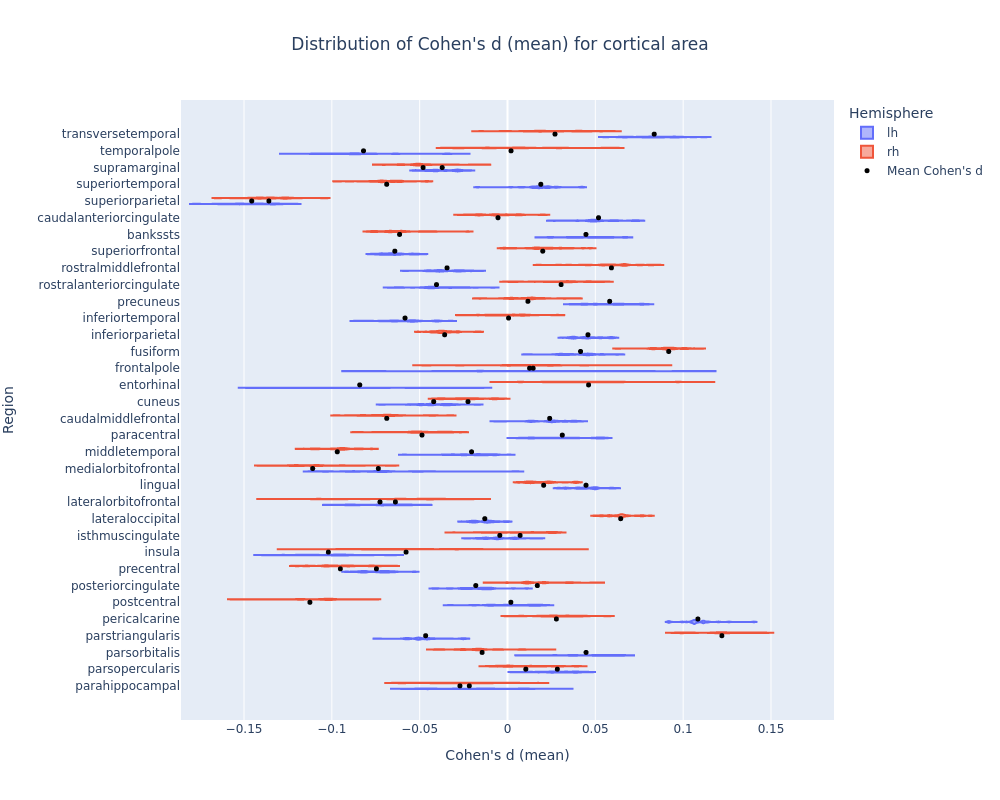

In [34]:
fig = px.violin(
    cohend_df[cohend_df["region"].isin(regions_template)],
    x="cohen_d_mean",
    y="region",
    box=False,
    color="hemisphere",
    points=False,
    height=800,
    title="Distribution of Cohen's d (mean) for cortical area",
).update_traces(orientation="h")
# Add point for the mean Cohen's d
mean_cohen_d = (
    cohend_df.groupby(["region", "hemisphere"])["cohen_d_mean"].mean().reset_index()
)
mean_cohen_d = mean_cohen_d.rename(columns={"cohen_d_mean": "mean_cohen_d"})
mean_cohen_d = mean_cohen_d[mean_cohen_d["region"].isin(regions_template)]
fig.add_trace(
    go.Scatter(
        x=mean_cohen_d["mean_cohen_d"],
        y=mean_cohen_d["region"],
        mode="markers",
        marker=dict(color="black", size=5, symbol="circle"),
        name="Mean Cohen's d",
    )
)
fig.update_layout(
    xaxis_title="Cohen's d (mean)",
    yaxis_title="Region",
    title_x=0.5,
    legend_title_text="Hemisphere",
    width=1000,
    height=800,
)
max_cohen_d = cohend_df["cohen_d_mean"].max()
min_cohen_d = cohend_df["cohen_d_mean"].min()
max_abs = max(abs(max_cohen_d), abs(min_cohen_d)) * 1.05
fig.update_xaxes(
    range=[-max_abs, max_abs],
    # tickvals=np.arange(-max_abs, max_abs + 0.1, 0.1),
    # ticktext=[f"{x:.1f}" for x in np.arange(-max_abs, max_abs + 0.1, 0.1)],
)
filename = figures_dir / "cohen_d_mean_cortical_area.png"
print_figure(fig, filename=filename)

## Numerical-Anatomical Variability Ratio

'Number unique subjects/visits in population: 566'

'Number unique subjects/visits in population: 566'

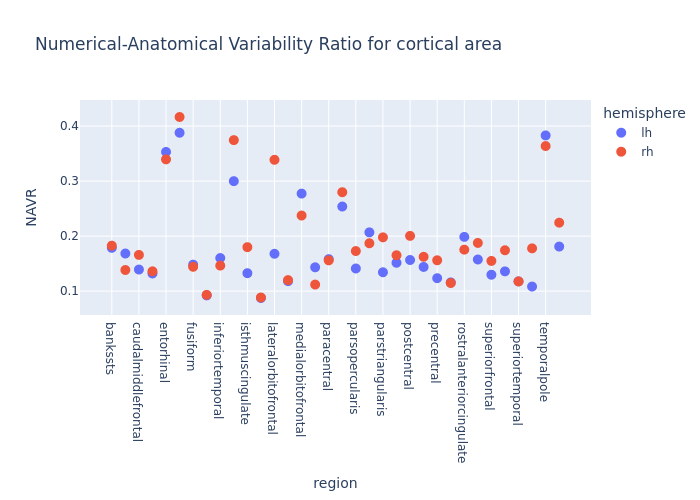

In [42]:
pop = np.concatenate([pop1, pop2])
card_num, var_num = compute_numerical_variability_cortical_metric("area", pop)
card_anat, var_anat = compute_anatomical_variability_cortical_metric("area", pop)
var_num["area"] = var_num["area"].astype(np.float64)
var_anat["area"] = var_anat["area"].astype(np.float64)

navr = var_num.groupby(["region", "hemisphere"])["area"].mean().apply(
    np.sqrt
) / var_anat.groupby(["region", "hemisphere"])["area"].mean().apply(np.sqrt)
navr_df = pd.DataFrame(navr).reset_index()
navr_df.rename(columns={"area": "NAVR"}, inplace=True)
navr_df = navr_df[navr_df["region"].isin(regions_template)]
fig = (
    px.scatter(
        navr_df,
        x="region",
        y="NAVR",
        color="hemisphere",
        hover_name="region",
        title="Numerical-Anatomical Variability Ratio for cortical area",
    )
    .update_traces(marker=dict(size=10))
    .update_yaxes(exponentformat="e")
)
filename = figures_dir / "navr_cortical_area.png"
print_figure(fig, filename=filename)


In [41]:
# Export NAVR results to CSV
alpha = 2 / np.sqrt(pop1.shape[0] + pop2.shape[0])  # Correction factor for NAVR
navr_df["NAVR_corrected"] = alpha * navr_df["NAVR"]  # Apply the alpha correction
navr_df["correction"] = alpha
navr_df["population_size"] = pop1.shape[0] + pop2.shape[0]
navr_df.to_csv(csv_dir / "navr_cortical_area.csv", index=False)


## Cohen's d coefficient standard deviation estimation

,hemisphere,region,cohen_d_mean,ci_lower,ci_upper,observed_std,error_plus,error_minus
0,lh,bankssts,0.013944,0.013863,0.014026,0.013944,0.000081,-0.000082
1,lh,caudalanteriorcingulate,0.012753,0.012651,0.012852,0.012753,0.000102,-0.000100
2,lh,caudalmiddlefrontal,0.011823,0.011714,0.011932,0.011822,0.000108,-0.000110
3,lh,cuneus,0.010650,0.010542,0.010763,0.010650,0.000108,-0.000113
4,lh,entorhinal,0.035109,0.034880,0.035335,0.035108,0.000228,-0.000226
...,...,...,...,...,...,...,...,...
63,rh,superiorparietal,0.012402,0.012284,0.012522,0.012401,0.000118,-0.000121
64,rh,superiortemporal,0.011306,0.011201,0.011416,0.011306,0.000105,-0.000110
65,rh,supramarginal,0.015214,0.015081,0.015347,0.015213,0.000133,-0.000134
66,rh,temporalpole,0.024612,0.024400,0.024821,0.024611,0.000212,-0.000210


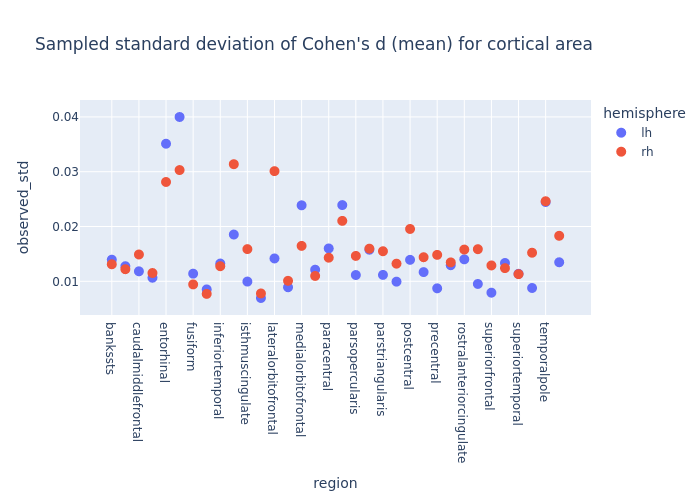

In [36]:
cohend_d_std = (
    cohend_df.groupby(["hemisphere", "region"])["cohen_d_mean"].std().reset_index()
)
cohend_d_std = cohend_d_std[cohend_d_std.region.isin(regions_template)]
cohend_d_std = cohend_d_std.merge(
    cohend_d_CI_df, on=["region", "hemisphere"], how="left"
)


cohend_d_std["error_plus"] = cohend_d_std["observed_std"] - cohend_d_std["ci_lower"]
cohend_d_std["error_minus"] = cohend_d_std["observed_std"] - cohend_d_std["ci_upper"]

display(cohend_d_std)

fig = px.scatter(
    cohend_d_std,
    x="region",
    y="observed_std",
    color="hemisphere",
    error_y="error_plus",
    error_y_minus="error_minus",
    hover_name="region",
    title="Sampled standard deviation of Cohen's d (mean) for cortical area",
).update_traces(marker=dict(size=10))
filename = figures_dir / "cohen_d_std_cortical_area.png"
print_figure(fig, filename=filename)

In [37]:
# Difference between ratio and cohen's d std estimated from the same data
cohend_d_std["NAVR"] = navr_df["NAVR"].values

alpha = np.sqrt(4 / (pop1.shape[0] + pop2.shape[0]))
print(f"2/sqrt(D) factor: {alpha:.4f}")

cohend_d_std["ratio"] = cohend_d_std["cohen_d_mean"] / (alpha * cohend_d_std["NAVR"])

# get mean CI with bootstrap
bootstrap_results = bootstrap(
    (cohend_d_std["ratio"].values,),
    np.mean,
    confidence_level=0.95,
    n_resamples=10000,
    random_state=42,
)
observed_value = bootstrap_results.bootstrap_distribution.mean()
ci_lower = bootstrap_results.confidence_interval.low
ci_upper = bootstrap_results.confidence_interval.high
print(
    f"Bootstrap confidence interval for mean ratio: {observed_value:.4f} with CI at 95% [{ci_lower:.4f}, {ci_upper:.4f}]"
)

cohend_d_std = cohend_d_std[cohend_d_std["region"].isin(regions_template)]
fig = px.scatter(
    cohend_d_std,
    x="region",
    y="ratio",
    hover_name="region",
    color="hemisphere",
    title="Ratio between NAVR and Cohen's d std for cortical area",
).update_traces(marker=dict(size=10))
# Add horizontal line with CI at 95%
fig.add_hline(
    y=observed_value,
    line_color="rgba(0,0,0,.25)",
    line_dash="solid",
    line_width=1,
    annotation_text=f"Mean ratio: {observed_value:.2f}",
    annotation_position="top right",
)
fig.add_trace(
    go.Scatter(
        x=np.concatenate([cohend_d_std["region"], cohend_d_std["region"][::-1]]),
        y=[ci_lower] * len(cohend_d_std["region"])
        + [ci_upper] * len(cohend_d_std["region"]),
        fill="toself",
        fillcolor="rgba(125, 125, 125, 0.1)",
        line=dict(color="rgba(255,0,0,0.2)", width=1, dash="dot"),
        hoverinfo="skip",
        showlegend=False,
    )
)

2/sqrt(D) factor: 0.0841
Bootstrap confidence interval for mean ratio: 1.1451 with CI at 95% [1.0081, 1.3115]
